In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Recurrence 1:
# T(n) = T(n/2) + n

calls_1 = 0

def T1(n):
    global calls_1
    calls_1 += 1

    if n <= 1:
        return 1
    return T1(n // 2) + n


# Recurrence 2:
# T(n) = 2T(n/2) + n

calls_2 = 0

def T2(n):
    global calls_2
    calls_2 += 1

    if n <= 1:
        return 1
    return 2 * T2(n // 2) + n

In [3]:
def measure(func, n):
    start = time.perf_counter()
    val = func(n)
    end = time.perf_counter()
    return val, end - start

In [4]:
sizes = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

results = []

for n in sizes:
    # T1 
    calls_1 = 0
    val1, t1 = measure(T1, n)

    results.append({
        "Recurrence": "T(n) = T(n/2) + n",
        "n": n,
        "Value": val1,
        "Calls": calls_1,
        "Time (sec)": t1
    })

    # T2
    calls_2 = 0
    val2, t2 = measure(T2, n)

    results.append({
        "Recurrence": "T(n) = 2T(n/2) + n",
        "n": n,
        "Value": val2,
        "Calls": calls_2,
        "Time (sec)": t2
    })

In [5]:
df = pd.DataFrame(results)
print("\nTask 4 Table:\n")
print(df)


Task 4 Table:

            Recurrence     n  Value  Calls    Time (sec)
0    T(n) = T(n/2) + n     2      3      2  1.499895e-06
1   T(n) = 2T(n/2) + n     2      4      2  1.000008e-06
2    T(n) = T(n/2) + n     4      7      3  7.001217e-07
3   T(n) = 2T(n/2) + n     4     12      3  6.000046e-07
4    T(n) = T(n/2) + n     8     15      4  4.000030e-07
5   T(n) = 2T(n/2) + n     8     32      4  5.001202e-07
6    T(n) = T(n/2) + n    16     31      5  4.998874e-07
7   T(n) = 2T(n/2) + n    16     80      5  4.998874e-07
8    T(n) = T(n/2) + n    32     63      6  6.000046e-07
9   T(n) = 2T(n/2) + n    32    192      6  6.000046e-07
10   T(n) = T(n/2) + n    64    127      7  6.000046e-07
11  T(n) = 2T(n/2) + n    64    448      7  6.998889e-07
12   T(n) = T(n/2) + n   128    255      8  7.001217e-07
13  T(n) = 2T(n/2) + n   128   1024      8  8.998904e-07
14   T(n) = T(n/2) + n   256    511      9  7.001217e-07
15  T(n) = 2T(n/2) + n   256   2304      9  8.000061e-07
16   T(n) = T(n

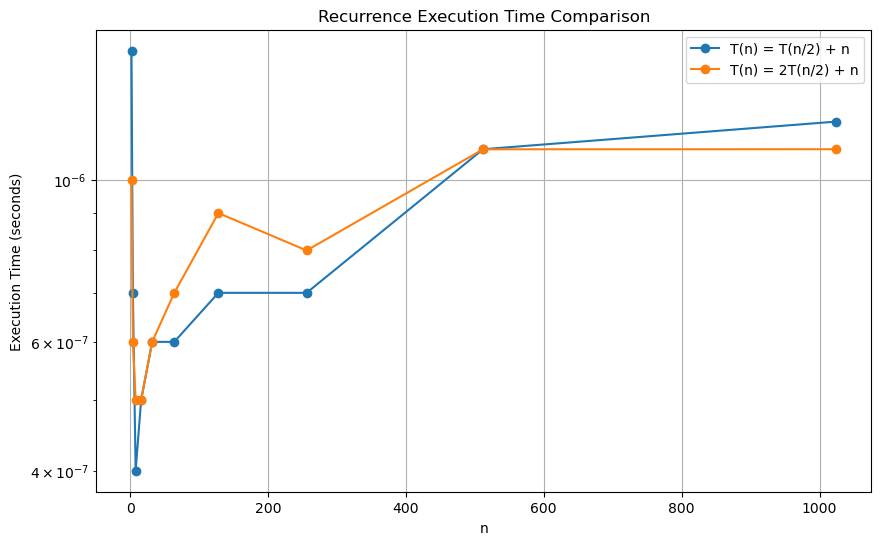

In [6]:
plt.figure(figsize=(10, 6))

for rec in df["Recurrence"].unique():
    temp = df[df["Recurrence"] == rec]
    plt.plot(temp["n"], temp["Time (sec)"], marker="o", label=rec)

plt.xlabel("n")
plt.ylabel("Execution Time (seconds)")
plt.title("Recurrence Execution Time Comparison")
plt.legend()
plt.grid(True)

plt.yscale("log")
plt.show()